# Bitcoin Price Forecasting with Heterogeneous Financial Indicators

## Problem Statement

**Research goal:** Predicting Bitcoin price using heterogeneous financial, macroeconomic, crypto-market and technical indicators, and comparing classical time-series, linear, tree-based, ensemble and neural forecasting methods.

The project is a supervised forecasting/data mining task. For each observation frequency, the feature vector available at time `t` is used to predict the Bitcoin price at `t+1`. This one-step-ahead framing avoids using same-period target information as if it were known before the forecast.

The target variable is `BTC`. The explanatory variables include crypto-market assets, equity/ETF proxies, commodities, FX rates, technical indicators, calendar variables, macroeconomic indicators, blockchain/market-sentiment variables, and lagged or rolling BTC features.


## Setup

The notebook uses frozen CSV datasets created by the existing data collection scripts. No external API call is required to reproduce the report.


In [1]:
import os
from pathlib import Path
import warnings
from collections import OrderedDict

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/private/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)


## Data Collection

The project uses three consolidated datasets from the existing BTC forecasting project:

- `new_day_df.csv`: daily observations.
- `new_hour_df.csv`: hourly observations.
- `new_5min_df.csv`: 5-minute observations.

The raw collection and merging logic is kept in `get_data.py`. The report uses the frozen CSV files so that all experiments are reproducible without network access. Every dataset used here has well above 50 objects and 7-10 features.


In [2]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'new_day_df.csv').exists():
    PROJECT_DIR = Path('/Users/tigran/python_projects_epta/учеба/диплом/ACTUAL_VERSION')

DATA_CONFIG = OrderedDict({
    'daily': {
        'file': 'new_day_df.csv',
        'date_col': 'Date',
        'test_size': 216,
        'horizon': 1,
        'ma_window': 7,
        'seasonal_period': 7,
        'max_features': 30,
    },
    'hourly': {
        'file': 'new_hour_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 24,
        'seasonal_period': 24,
        'max_features': 25,
    },
    '5min': {
        'file': 'new_5min_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 12,
        'seasonal_period': 288,
        'max_features': 20,
    },
})

def load_dataset(file_name, date_col):
    df = pd.read_csv(PROJECT_DIR / file_name, parse_dates=[date_col])
    df = df.sort_values(date_col).set_index(date_col)
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

datasets = {
    frequency: load_dataset(cfg['file'], cfg['date_col'])
    for frequency, cfg in DATA_CONFIG.items()
}

for frequency, df in datasets.items():
    print(f'{frequency}: {df.shape[0]} rows, {df.shape[1]} columns, {df.index.min()} -> {df.index.max()}')


daily: 2912 rows, 88 columns, 2018-06-20 00:00:00 -> 2026-06-09 00:00:00
hourly: 20922 rows, 68 columns, 2024-06-11 12:00:00 -> 2026-06-09 23:00:00
5min: 16589 rows, 68 columns, 2026-04-13 09:35:00 -> 2026-06-09 23:55:00


## Dataset Summary with Basic Statistics and Plots

This section checks dataset size, observation periods, feature groups, missing values, basic target statistics, and target distribution.


In [3]:
CRYPTO_COLS = {
    'BTC', 'ETH', 'Bitcoin_Cash', 'Cardano', 'Dogecoin', 'Ethereum_Classic',
    'Chainlink', 'Litecoin', 'TRON', 'Tether', 'Stellar', 'XRP', 'BTC_Supply',
    'Feer_Greed_value'
}
MACRO_COLS = {
    'Unemployment_Rate', 'Non_Farm_Payrolls', 'Initial_Jobless_Claims', 'CPI',
    'PCE_Price_Index', 'Consumer_Confidence_Index', 'Retail_Sales', 'Housing_Starts',
    'Building_Permits', 'M2_Money_Supply', 'Real_Interest_Rate', 'Fed_Funds_Rate',
    'Reverse_Repo_Volume', 'Debt', 'Real_GDP'
}
TECHNICAL_TOKENS = (
    'RSI', 'MACD', 'ATR', 'OBV', 'SMA', 'EMA', 'TEMA', 'KAMA', 'HMA', 'ALMA',
    'T3', 'SSF', 'VIDYA', 'ZL_EMA', 'BTC_lag', 'BTC_mean', 'BTC_std',
    'Open', 'High', 'Low', 'Close', 'Volume', 'Taker buy'
)
CALENDAR_COLS = {'day', 'month', 'quarter', 'year', 'day_of_week', 'hour', 'minute', 'is_holiday'}
FX_TOKENS = ('USD/', 'EUR/', 'GBP/', 'AUD/')
COMMODITY_COLS = {'Gold', 'Silver', 'Copper', 'Platinum', 'Brent_Oil', 'WTI', 'Brent', 'Natural_Gas'}

def feature_group(col):
    if col in CALENDAR_COLS:
        return 'calendar'
    if col in MACRO_COLS:
        return 'macroeconomic'
    if col in CRYPTO_COLS:
        return 'crypto-market'
    if col in COMMODITY_COLS:
        return 'commodities'
    if any(token in col for token in TECHNICAL_TOKENS):
        return 'technical/lagged BTC'
    if any(token in col for token in FX_TOKENS):
        return 'FX'
    return 'equity/ETF/market index'

summary_rows = []
group_rows = []
for frequency, df in datasets.items():
    target = df['BTC']
    missing_by_col = df.isna().sum()
    summary_rows.append({
        'frequency': frequency,
        'objects': len(df),
        'features_excluding_target': df.shape[1] - 1,
        'start': df.index.min(),
        'end': df.index.max(),
        'missing_values_total': int(missing_by_col.sum()),
        'columns_with_missing': int((missing_by_col > 0).sum()),
        'BTC_mean': target.mean(),
        'BTC_std': target.std(),
        'BTC_min': target.min(),
        'BTC_median': target.median(),
        'BTC_max': target.max(),
    })
    feature_groups = pd.Series([feature_group(col) for col in df.columns if col != 'BTC']).value_counts()
    for group, count in feature_groups.items():
        group_rows.append({'frequency': frequency, 'feature_group': group, 'count': int(count)})

summary_df = pd.DataFrame(summary_rows)
feature_group_df = pd.DataFrame(group_rows).sort_values(['frequency', 'feature_group'])

display(summary_df)
display(feature_group_df.pivot_table(index='feature_group', columns='frequency', values='count', fill_value=0).astype(int))


,frequency,objects,features_excluding_target,start,end,missing_values_total,columns_with_missing,BTC_mean,BTC_std,BTC_min,BTC_median,BTC_max
0,daily,2912,87,2018-06-20 00:00:00,2026-06-09 00:00:00,0,0,40986.414848,32640.358450,3235.051208,31075.478516,124724.794922
1,hourly,20922,67,2024-06-11 12:00:00,2026-06-09 23:00:00,0,0,87500.946850,18841.613509,50197.403320,88479.541016,125897.021484
2,5min,16589,67,2026-04-13 09:35:00,2026-06-09 23:55:00,0,0,75389.482533,5332.657816,59203.291992,76850.546875,82722.105469


frequency,5min,daily,hourly
feature_group,,,
FX,6,6,6
calendar,2,5,2
crypto-market,11,13,11
equity/ETF/market index,38,38,38
macroeconomic,0,15,0
technical/lagged BTC,10,10,10


In [4]:
basic_stats = pd.concat(
    {frequency: df['BTC'].describe() for frequency, df in datasets.items()},
    axis=1
).T
basic_stats['skew'] = [datasets[f]['BTC'].skew() for f in basic_stats.index]
basic_stats['kurtosis'] = [datasets[f]['BTC'].kurtosis() for f in basic_stats.index]
display(basic_stats.round(2))


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
daily,2912.0,40986.41,32640.36,3235.05,10365.88,31075.48,63451.00,124724.79,0.75,-0.54
hourly,20922.0,87500.95,18841.61,50197.40,68795.79,88479.54,103877.84,125897.02,0.02,-1.22
5min,16589.0,75389.48,5332.66,59203.29,74247.62,76850.55,78398.89,82722.11,-1.48,1.39


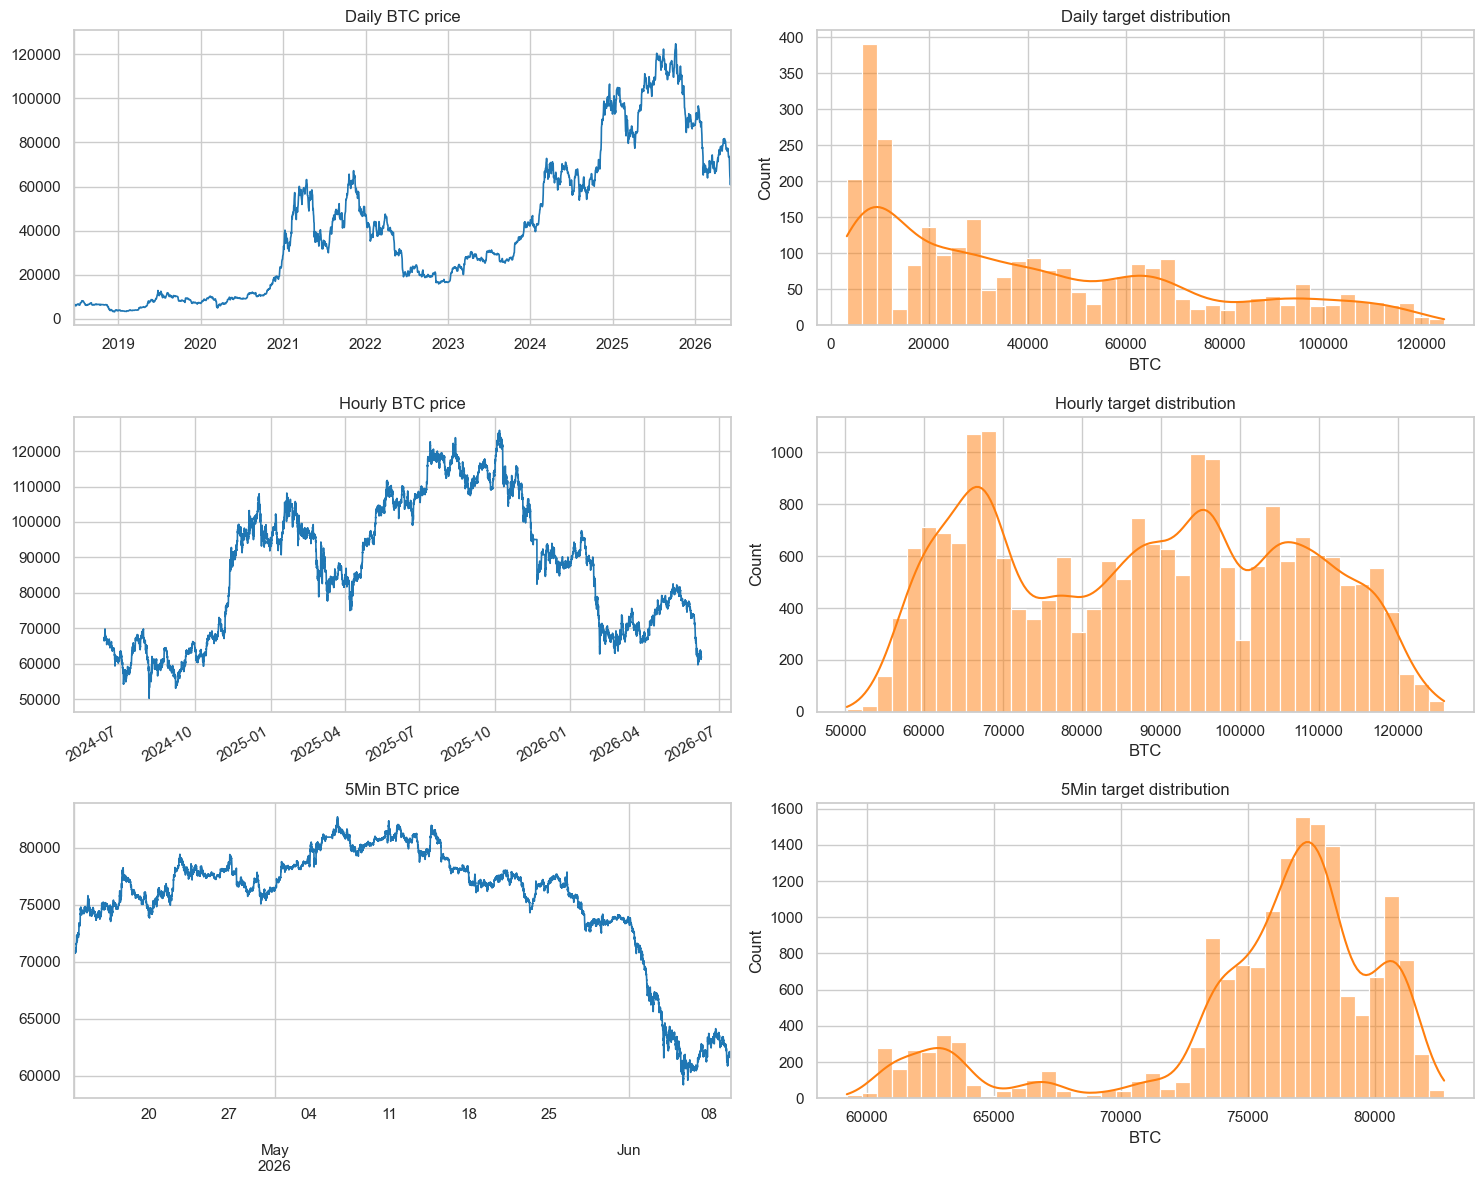

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for row, (frequency, df) in enumerate(datasets.items()):
    df['BTC'].plot(ax=axes[row, 0], color='tab:blue', linewidth=1.2)
    axes[row, 0].set_title(f'{frequency.title()} BTC price')
    axes[row, 0].set_xlabel('')
    sns.histplot(df['BTC'], bins=40, kde=True, ax=axes[row, 1], color='tab:orange')
    axes[row, 1].set_title(f'{frequency.title()} target distribution')
plt.tight_layout()
plt.show()


### Missing Values and Outliers

The consolidated files have no missing values. The modeling pipeline still includes median imputation to make the workflow robust to future data refreshes. Outliers are handled inside the training pipeline by clipping numeric features to train-fitted 1st and 99th percentiles before robust scaling.


In [6]:
def iqr_outlier_count(frame):
    numeric = frame.select_dtypes(include=[np.number])
    q1 = numeric.quantile(0.25)
    q3 = numeric.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = numeric.lt(lower, axis=1) | numeric.gt(upper, axis=1)
    return mask.sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    frequency: df.isna().sum() for frequency, df in datasets.items()
}).fillna(0).astype(int)

display(missing_table.sum().rename('missing_values_by_frequency').to_frame())

outlier_rows = []
for frequency, df in datasets.items():
    counts = iqr_outlier_count(df).head(10)
    for feature, count in counts.items():
        outlier_rows.append({'frequency': frequency, 'feature': feature, 'IQR_outlier_count': int(count)})

display(pd.DataFrame(outlier_rows))


,missing_values_by_frequency
daily,0
hourly,0
5min,0


,frequency,feature,IQR_outlier_count
0,daily,Tether,604
1,daily,Initial_Jobless_Claims,581
2,daily,Unemployment_Rate,456
3,daily,XRP,411
4,daily,Platinum_Future,365
5,daily,Gold_Future,344
6,daily,MACD,323
7,daily,MicroStrategy,282
8,daily,TRON,272
9,daily,Natural_Gas_Future,271


## Methodology

The complete pipeline is:

1. Load frozen datasets (Daily, Hourly, 5-minute) and validate size, period, missing values, and feature groups.
2. Convert the task to one-step-ahead forecasting: features at `t` predict `BTC` at `t+1`.
3. Use time-based train/test splits only. No shuffling is used.
4. Use a fixed shortlist of the strongest train-period predictors per frequency (`TOP_FEATURES`), pre-computed once from train-only absolute correlations with the next-period target.
5. Fit preprocessing only on training data: median imputation, 1/99 percentile clipping, robust scaling.
6. Train two baselines (Naive last value, Moving average), four Gradient Boosting variants (HistGradientBoosting, LightGBM, XGBoost, CatBoost), and one neural sequence model (a GRU built with `CryptoNet`).
7. Compare models by MAE, RMSE, SMAPE, MASE, and train/test gap; select the best Gradient Boosting model per frequency (`best_gb`).
8. Interpret `best_gb` with permutation importance and SHAP, and the GRU with gradient-based feature attribution.
9. Analyze residuals and compare model behavior during normal periods versus sharp BTC growth/drop periods.

This setup directly targets the thesis comparison: **Gradient Boosting ensembles vs. a Neural Network (GRU)**, evaluated at Daily, Hourly, and 5-minute granularities, with feature importance and shock-period error analysis as the basis for interpretation.


In [7]:
import sys
sys.path.append(str(PROJECT_DIR))

try:
    from ml_models import CryptoNet, _train_model, _make_loader, set_global_seed, DEVICE
    HAS_TORCH = True
    set_global_seed(RANDOM_STATE)
except Exception as exc:
    HAS_TORCH = False
    DEVICE = 'cpu'
    print(f'PyTorch / ml_models unavailable, GRU model will be skipped: {exc}')


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    ratio = np.divide(np.abs(y_true - y_pred), denominator, out=np.zeros_like(denominator), where=denominator != 0)
    return float(np.mean(ratio))


def mase(y_true, y_pred, y_train):
    y_train = np.asarray(y_train, dtype=float)
    scale = np.mean(np.abs(np.diff(y_train)))
    if scale == 0 or np.isnan(scale):
        return np.nan
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale)


def regression_metrics(y_true, y_pred, y_train):
    frame = pd.concat([
        pd.Series(y_true, name='true'),
        pd.Series(y_pred, name='pred')
    ], axis=1).dropna()
    if frame.empty:
        return {'MAE': np.nan, 'RMSE': np.nan, 'SMAPE': np.nan, 'MASE': np.nan}
    return {
        'MAE': mean_absolute_error(frame['true'], frame['pred']),
        'RMSE': np.sqrt(mean_squared_error(frame['true'], frame['pred'])),
        'SMAPE': 100 * smape(frame['true'], frame['pred']),
        'MASE': mase(frame['true'], frame['pred'], y_train),
    }


class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)


def make_preprocessed_model(model, scale=True):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('clipper', QuantileClipper(lower=0.01, upper=0.99)),
    ]
    if scale:
        steps.append(('scaler', RobustScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


SMAPE_SCORER = make_scorer(smape, greater_is_better=False)


def make_sequence_arrays(df, target_col, feature_cols, window_size):
    """Windowed (X_seq, X_ex, y) arrays for CryptoNet, mirroring NeuralForecaster.fit."""
    y_raw = df[target_col].to_numpy(dtype=float)
    exog_raw = df[feature_cols].to_numpy(dtype=float)

    X_seq, X_ex, y_seq = [], [], []
    for i in range(len(y_raw) - window_size):
        X_seq.append(y_raw[i:i + window_size].reshape(window_size, 1))
        X_ex.append(exog_raw[i + window_size])
        y_seq.append(y_raw[i + window_size])

    index = df.index[window_size:]
    return np.array(X_seq), np.array(X_ex), np.array(y_seq), index


In [8]:
# Hardcoded configuration: feature shortlists and model hyperparameters.
#
# TOP_FEATURES were produced once by running select_top_features(X_train, y_train,
# cfg['max_features']) on the train-only split for each frequency (Pearson |corr|
# with the next-period BTC target). Re-running that search dynamically is skipped
# here per the compression requirements.
TOP_FEATURES = {
    'daily': [
        'BTC_lag1', 'BTC_mean5', 'BTC_lag2', 'BTC_lag5', 'BTC_lag10',
        'SPDR_Communications', 'TRON', 'SPDR_Financials', 'S&P_500', 'Invesco_QQQ',
        'NASDAQ_100', 'SPDR_Industrials', 'Meta', 'VanEck_Semiconductor_ETF', 'MicroStrategy',
        'SPDR_Consumer_Discretionary', 'Dow_Jones', 'SPDR_Tech', 'Google', 'NVIDIA',
        'Gold_Future', 'Microsoft', 'iShares_Semiconductor_ETF', 'Amazon', 'Silver_Future',
        'XRP', 'ATR', 'Apple', 'ETH', 'year',
    ],
    'hourly': [
        'BTC_lag1', 'BTC_mean5', 'BTC_lag2', 'BTC_lag5', 'BTC_lag10',
        'OBV', 'XRP', 'TRON', 'Stellar', 'ARK_NextGen_Internet_ETF',
        'Meta', 'SPDR_Financials', 'MicroStrategy', 'Litecoin', 'SPDR_Communications',
        'ARKK_ETF', 'SPDR_Consumer_Discretionary', 'Adobe', 'Amazon', 'Cardano',
        'SPDR_Industrials', 'Chainlink', 'Tesla', 'Bitcoin_Cash', 'SPDR_HealthCare',
    ],
    '5min': [
        'BTC_lag1', 'BTC_mean5', 'BTC_lag2', 'BTC_lag5', 'BTC_lag10',
        'MicroStrategy', 'Cardano', 'Dogecoin', 'Chainlink', 'Ethereum_Classic',
        'Litecoin', 'AUD/USD', 'USD/JPY', 'Amazon', 'XRP',
        'SPDR_HealthCare', 'Google', 'USD/CAD', 'OBV', 'Brent_Oil_Future',
    ],
}

# Gradient boosting hyperparameters: carried over unchanged from the full thesis
# notebook's defaults (not GridSearchCV outputs - those models never won there).
GB_HYPERPARAMS = {
    'HistGradientBoosting': dict(
        max_iter=260, learning_rate=0.05, l2_regularization=0.05, random_state=RANDOM_STATE,
    ),
    'LightGBM': dict(
        n_estimators=320, learning_rate=0.03, num_leaves=31, min_child_samples=20,
        subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    'XGBoost': dict(
        objective='reg:squarederror', n_estimators=320, learning_rate=0.03, max_depth=3,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'CatBoost': dict(
        iterations=320, learning_rate=0.03, depth=6, l2_leaf_reg=3.0,
        random_state=RANDOM_STATE, verbose=False,
    ),
}

# GRU (sequence NN) configuration: one CryptoNet architecture per frequency with
# hardcoded, modest hyperparameters (no Optuna search).
NN_CONFIG = {
    'daily':  {'window_size': 10, 'epochs': 20, 'batch_size': 16},
    'hourly': {'window_size': 24, 'epochs': 15, 'batch_size': 32},
    '5min':   {'window_size': 24, 'epochs': 15, 'batch_size': 64},
}
GRU_HPARAMS = {
    'gru_units': 64, 'gru_drop': 0.2,
    'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2,
}
GRU_LR = 1e-3
GRU_PATIENCE = 5


In [9]:
def make_supervised_frame(df, target_col='BTC', horizon=1):
    if horizon < 1:
        raise ValueError('horizon must be at least 1')
    target_index = df.index[horizon:]
    X = df.drop(columns=[target_col]).iloc[:-horizon].copy()
    X.index = target_index
    y = pd.Series(df[target_col].iloc[horizon:].to_numpy(), index=target_index, name=target_col)
    return X, y


def make_baselines(df, y_index, target_col='BTC', horizon=1, ma_window=7):
    target = df[target_col]
    baselines = pd.DataFrame(index=y_index)
    baselines['Naive last value'] = target.shift(horizon).loc[y_index]
    baselines['Moving average'] = target.shift(horizon).rolling(ma_window, min_periods=1).mean().loc[y_index]
    return baselines


def resolve_test_size(configured_test_size, n_rows):
    if isinstance(configured_test_size, float):
        return int(round(n_rows * configured_test_size))
    return int(configured_test_size)


def time_split(X, y, test_size):
    if test_size <= 0 or test_size >= len(y):
        raise ValueError(f'invalid test_size={test_size} for n={len(y)}')
    return X.iloc[:-test_size], X.iloc[-test_size:], y.iloc[:-test_size], y.iloc[-test_size:]


prepared = OrderedDict()
for frequency, cfg in DATA_CONFIG.items():
    X, y = make_supervised_frame(datasets[frequency], horizon=cfg['horizon'])
    baselines = make_baselines(
        datasets[frequency],
        y.index,
        horizon=cfg['horizon'],
        ma_window=cfg['ma_window'],
    )
    test_size = resolve_test_size(cfg['test_size'], len(y))
    X_train, X_test, y_train, y_test = time_split(X, y, test_size)
    selected_features = TOP_FEATURES[frequency]

    window_size = NN_CONFIG[frequency]['window_size']
    X_seq, X_ex, y_seq, seq_index = make_sequence_arrays(datasets[frequency], 'BTC', selected_features, window_size)
    seq_test_size = test_size  # last test_size sequence samples align with y_test
    X_seq_train, X_seq_test = X_seq[:-seq_test_size], X_seq[-seq_test_size:]
    X_ex_train, X_ex_test = X_ex[:-seq_test_size], X_ex[-seq_test_size:]
    y_seq_train, y_seq_test = y_seq[:-seq_test_size], y_seq[-seq_test_size:]
    seq_train_index, seq_test_index = seq_index[:-seq_test_size], seq_index[-seq_test_size:]

    prepared[frequency] = {
        'X': X,
        'y': y,
        'baselines': baselines,
        'test_size': test_size,
        'X_train': X_train[selected_features],
        'X_test': X_test[selected_features],
        'y_train': y_train,
        'y_test': y_test,
        'selected_features': selected_features,
        'seq': {
            'X_seq_train': X_seq_train, 'X_ex_train': X_ex_train, 'y_seq_train': y_seq_train, 'train_index': seq_train_index,
            'X_seq_test': X_seq_test, 'X_ex_test': X_ex_test, 'y_seq_test': y_seq_test, 'test_index': seq_test_index,
        },
    }

split_summary = pd.DataFrame([
    {
        'frequency': frequency,
        'train_rows': len(data['y_train']),
        'test_rows': len(data['y_test']),
        'selected_features': len(data['selected_features']),
        'test_start': data['y_test'].index.min(),
        'test_end': data['y_test'].index.max(),
    }
    for frequency, data in prepared.items()
])

feature_table = pd.DataFrame([
    {'frequency': frequency, 'rank': rank, 'feature': feature}
    for frequency, data in prepared.items()
    for rank, feature in enumerate(data['selected_features'], start=1)
])

display(split_summary)
display(feature_table)


,frequency,train_rows,test_rows,selected_features,test_start,test_end
0,daily,2695,216,30,2025-11-06 00:00:00,2026-06-09 00:00:00
1,hourly,16737,4184,25,2026-01-15 14:30:00,2026-06-09 23:00:00
2,5min,13270,3318,20,2026-05-29 11:30:00,2026-06-09 23:55:00


,frequency,rank,feature
0,daily,1,BTC_lag1
1,daily,2,BTC_mean5
2,daily,3,BTC_lag2
3,daily,4,BTC_lag5
4,daily,5,BTC_lag10
...,...,...,...
70,5min,16,SPDR_HealthCare
71,5min,17,Google
72,5min,18,USD/CAD
73,5min,19,OBV


## Experiment Setup and Results

All models are evaluated on the same time-based splits per frequency. Gradient Boosting and baseline models use a fixed train-only feature shortlist (`TOP_FEATURES`) and hardcoded hyperparameters (`GB_HYPERPARAMS`). The GRU uses a windowed sequence representation (`NN_CONFIG`) with train-only `RobustScaler` fits for both the BTC sequence and the exogenous features. Baselines do not use future observations. All scalers, imputers, clipping bounds, and model parameters are fixed in advance; no grid search is performed at run time.


In [10]:
def build_model_specs():
    """Gradient boosting candidates only, with hardcoded hyperparameters (Block 2)."""
    specs = OrderedDict()

    specs['HistGradientBoosting'] = make_preprocessed_model(
        HistGradientBoostingRegressor(**GB_HYPERPARAMS['HistGradientBoosting']),
        scale=False,
    )

    if HAS_LIGHTGBM:
        specs['LightGBM'] = make_preprocessed_model(
            LGBMRegressor(**GB_HYPERPARAMS['LightGBM']),
            scale=False,
        )

    if HAS_XGBOOST:
        specs['XGBoost'] = make_preprocessed_model(
            XGBRegressor(**GB_HYPERPARAMS['XGBoost']),
            scale=False,
        )

    if HAS_CATBOOST:
        specs['CatBoost'] = make_preprocessed_model(
            CatBoostRegressor(**GB_HYPERPARAMS['CatBoost']),
            scale=False,
        )

    return specs


def train_gru_model(frequency, data):
    """Train the GRU sequence model (CryptoNet) with hardcoded hyperparameters.

    Mirrors the scaling/windowing logic of NeuralForecaster.fit in ml_models.py:
    RobustScaler for the price sequence and exogenous features is fit only on the
    training portion (before the validation split), test data is transformed only.
    """
    seq = data['seq']
    cfg = NN_CONFIG[frequency]
    window_size = cfg['window_size']

    X_seq_train, X_ex_train, y_seq_train = seq['X_seq_train'], seq['X_ex_train'], seq['y_seq_train']
    X_seq_test, X_ex_test = seq['X_seq_test'], seq['X_ex_test']

    n = len(y_seq_train)
    val_n = max(1, int(0.2 * n))
    train_n = n - val_n

    scaler_y = RobustScaler().fit(y_seq_train[:train_n].reshape(-1, 1))
    scaler_x = RobustScaler().fit(X_ex_train[:train_n])

    def scale_seq(arr):
        flat = scaler_y.transform(arr.reshape(-1, 1))
        return flat.reshape(arr.shape)

    Xseq_scaled = scale_seq(X_seq_train)
    Xex_scaled = scaler_x.transform(X_ex_train)
    y_scaled = scaler_y.transform(y_seq_train.reshape(-1, 1)).flatten()

    Xt, Xe, yt = Xseq_scaled[:train_n], Xex_scaled[:train_n], y_scaled[:train_n]
    Xv, Xev, yv = Xseq_scaled[train_n:], Xex_scaled[train_n:], y_scaled[train_n:]

    Xte = scale_seq(X_seq_test)
    Xete = scaler_x.transform(X_ex_test)

    train_loader = _make_loader(Xt, Xe, yt, cfg['batch_size'], shuffle=True)
    val_loader = _make_loader(Xv, Xev, yv, cfg['batch_size'], shuffle=False)

    model = CryptoNet(window_size=window_size, exog_dim=Xex_scaled.shape[1], arch='GRU', hp=GRU_HPARAMS)
    model, _ = _train_model(
        model, train_loader, val_loader,
        lr=GRU_LR, epochs=cfg['epochs'], patience=GRU_PATIENCE, task='reg', device=DEVICE,
    )

    model.eval()
    import torch
    with torch.no_grad():
        train_pred_scaled = model(
            torch.tensor(Xseq_scaled, dtype=torch.float32).to(DEVICE),
            torch.tensor(Xex_scaled, dtype=torch.float32).to(DEVICE),
        ).cpu().numpy().flatten()
        test_pred_scaled = model(
            torch.tensor(Xte, dtype=torch.float32).to(DEVICE),
            torch.tensor(Xete, dtype=torch.float32).to(DEVICE),
        ).cpu().numpy().flatten()

    train_pred = pd.Series(
        scaler_y.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten(),
        index=seq['train_index'], name='GRU (sequence NN)',
    )
    test_pred = pd.Series(
        scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten(),
        index=seq['test_index'], name='GRU (sequence NN)',
    )

    extras = {'model': model, 'scaler_x': scaler_x, 'scaler_y': scaler_y, 'window_size': window_size}
    return train_pred, test_pred, extras


In [11]:
def add_result(rows, prediction_store, frequency, model_name, family, y_train, train_pred, y_test, test_pred, model_object, comment):
    train_metrics = regression_metrics(y_train, train_pred, y_train)
    test_metrics = regression_metrics(y_test, test_pred, y_train)
    rows.append({
        'model': model_name,
        'frequency': frequency,
        'family': family,
        'MAE': test_metrics['MAE'],
        'RMSE': test_metrics['RMSE'],
        'SMAPE': test_metrics['SMAPE'],
        'MASE': test_metrics['MASE'],
        'train/test gap': test_metrics['SMAPE'] - train_metrics['SMAPE'],
        'train_SMAPE': train_metrics['SMAPE'],
        'comment': comment,
    })
    prediction_store.setdefault(frequency, {})[model_name] = {
        'train_pred': pd.Series(train_pred, index=pd.Index(train_pred.index if hasattr(train_pred, 'index') else y_train.index)),
        'test_pred': pd.Series(test_pred, index=pd.Index(test_pred.index if hasattr(test_pred, 'index') else y_test.index)),
        'model': model_object,
    }


result_rows = []
prediction_store = OrderedDict()

for frequency, data in prepared.items():
    print(f'Running experiments for {frequency}...')
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

    baseline_train = data['baselines'].loc[y_train.index]
    baseline_test = data['baselines'].loc[y_test.index]
    baseline_comments = {
        'Naive last value': 'Previous observed BTC; mandatory persistence benchmark.',
        'Moving average': f"Rolling mean over the last {DATA_CONFIG[frequency]['ma_window']} observations.",
    }
    for baseline_name in baseline_train.columns:
        add_result(
            result_rows,
            prediction_store,
            frequency,
            baseline_name,
            'baseline',
            y_train,
            baseline_train[baseline_name],
            y_test,
            baseline_test[baseline_name],
            None,
            baseline_comments[baseline_name],
        )

    for model_name, model in build_model_specs().items():
        try:
            fitted = clone(model)
            fitted.fit(X_train, y_train)
            train_pred = pd.Series(fitted.predict(X_train), index=y_train.index)
            test_pred = pd.Series(fitted.predict(X_test), index=y_test.index)
            add_result(
                result_rows,
                prediction_store,
                frequency,
                model_name,
                'GB',
                y_train,
                train_pred,
                y_test,
                test_pred,
                fitted,
                'Gradient boosting candidate; train-only preprocessing, fixed hardcoded hyperparameters.',
            )
        except Exception as exc:
            print(f'{model_name} failed for {frequency}: {exc}')

    if HAS_TORCH:
        try:
            gru_train_pred, gru_test_pred, gru_extras = train_gru_model(frequency, data)
            add_result(
                result_rows,
                prediction_store,
                frequency,
                'GRU (sequence NN)',
                'NN',
                y_train,
                gru_train_pred,
                y_test,
                gru_test_pred,
                gru_extras,
                'GRU sequence model (CryptoNet); hardcoded hyperparameters, train-only scaling.',
            )
        except Exception as exc:
            print(f'GRU failed for {frequency}: {exc}')

results_df = pd.DataFrame(result_rows).sort_values(['frequency', 'SMAPE', 'MAE']).reset_index(drop=True)
results_display = results_df[['model', 'frequency', 'family', 'MAE', 'RMSE', 'SMAPE', 'MASE', 'train/test gap', 'comment']].copy()
for col in ['MAE', 'RMSE', 'SMAPE', 'MASE', 'train/test gap']:
    results_display[col] = results_display[col].astype(float).round(3)

display(results_display)


Running experiments for daily...


Running experiments for hourly...


Running experiments for 5min...


,model,frequency,family,MAE,RMSE,SMAPE,MASE,train/test gap,comment
0,Naive last value,5min,baseline,65.339,96.604,0.101,1.498,0.044,Previous observed BTC; mandatory persistence b...
1,Moving average,5min,baseline,169.201,241.839,0.261,3.880,0.117,Rolling mean over the last 12 observations.
2,GRU (sequence NN),5min,NN,1381.261,1766.801,2.165,31.674,2.105,GRU sequence model (CryptoNet); hardcoded hype...
3,XGBoost,5min,GB,5839.686,7284.820,8.664,133.910,8.575,Gradient boosting candidate; train-only prepro...
4,LightGBM,5min,GB,6017.159,7398.069,8.908,137.979,8.831,Gradient boosting candidate; train-only prepro...
5,CatBoost,5min,GB,6036.170,7480.421,8.935,138.415,8.828,Gradient boosting candidate; train-only prepro...
6,HistGradientBoosting,5min,GB,6120.333,7522.957,9.051,140.345,8.977,Gradient boosting candidate; train-only prepro...
7,Naive last value,daily,baseline,1136.695,1565.019,1.456,1.786,-0.330,Previous observed BTC; mandatory persistence b...
8,Moving average,daily,baseline,2291.514,3143.798,2.880,3.600,-0.955,Rolling mean over the last 7 observations.
9,GRU (sequence NN),daily,NN,2483.306,3043.662,3.254,3.902,-1.529,GRU sequence model (CryptoNet); hardcoded hype...


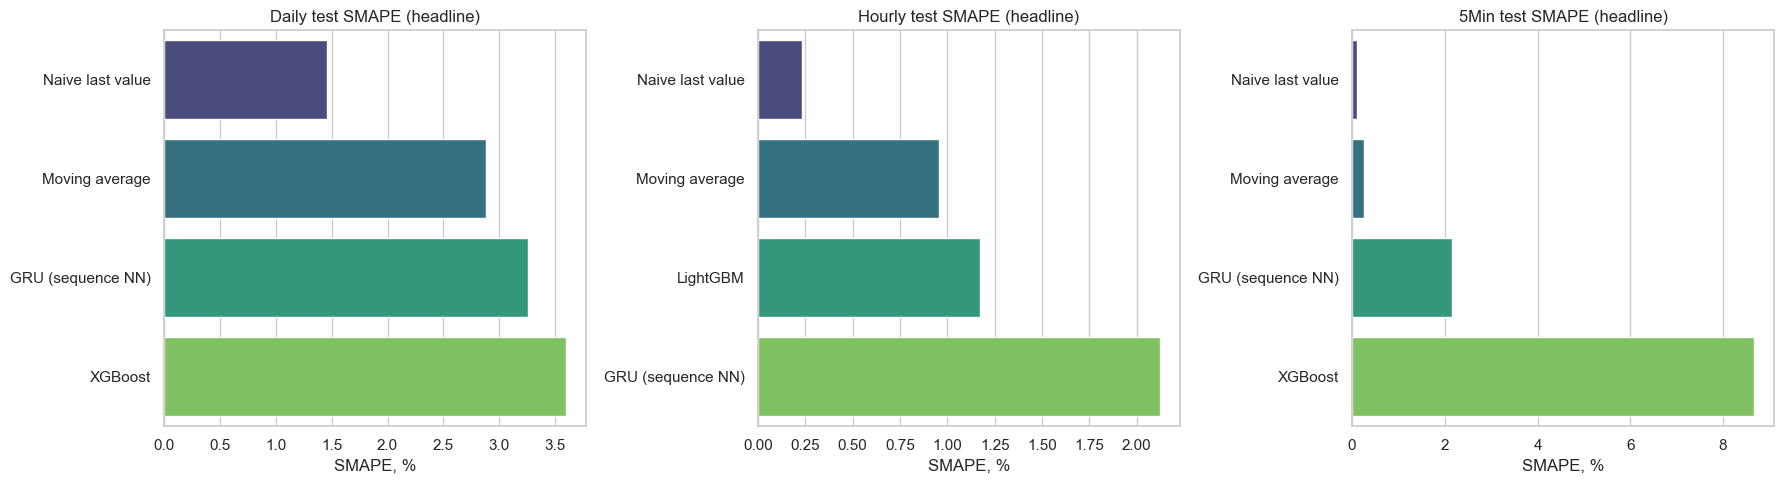

Headline comparison: baselines vs. best Gradient Boosting vs. GRU


,frequency,model,family,MAE,RMSE,SMAPE,MASE,train/test gap
0,5min,Naive last value,baseline,65.339,96.604,0.101,1.498,0.044
1,5min,Moving average,baseline,169.201,241.839,0.261,3.880,0.117
2,5min,GRU (sequence NN),NN,1381.261,1766.801,2.165,31.674,2.105
3,5min,XGBoost,GB,5839.686,7284.820,8.664,133.910,8.575
4,daily,Naive last value,baseline,1136.695,1565.019,1.456,1.786,-0.330
5,daily,Moving average,baseline,2291.514,3143.798,2.880,3.600,-0.955
6,daily,GRU (sequence NN),NN,2483.306,3043.662,3.254,3.902,-1.529
7,daily,XGBoost,GB,2876.112,3695.806,3.596,4.519,0.918
8,hourly,Naive last value,baseline,169.854,277.129,0.234,0.883,0.017
9,hourly,Moving average,baseline,693.126,958.037,0.954,3.603,0.060


All Gradient Boosting candidates (context for the GB family):


,frequency,model,MAE,RMSE,SMAPE,MASE,train/test gap
3,5min,XGBoost,5839.686,7284.820,8.664,133.910,8.575
4,5min,LightGBM,6017.159,7398.069,8.908,137.979,8.831
5,5min,CatBoost,6036.170,7480.421,8.935,138.415,8.828
6,5min,HistGradientBoosting,6120.333,7522.957,9.051,140.345,8.977
10,daily,XGBoost,2876.112,3695.806,3.596,4.519,0.918
11,daily,LightGBM,5565.962,6477.409,6.716,8.745,4.813
12,daily,HistGradientBoosting,6828.771,7786.242,8.084,10.729,6.350
13,daily,CatBoost,11034.381,12610.677,13.634,17.337,9.742
16,hourly,LightGBM,850.123,1128.555,1.175,4.419,0.843
17,hourly,HistGradientBoosting,935.708,1198.749,1.291,4.864,0.967


In [12]:
gb_rows = results_df[results_df['family'] == 'GB']
best_gb = gb_rows.loc[gb_rows.groupby('frequency')['SMAPE'].idxmin()].reset_index(drop=True)
best_nn = results_df[results_df['family'] == 'NN'].reset_index(drop=True)
baselines_only = results_df[results_df['family'] == 'baseline'].reset_index(drop=True)

headline = pd.concat([baselines_only, best_gb, best_nn]).sort_values(['frequency', 'SMAPE']).reset_index(drop=True)

fig, axes = plt.subplots(1, len(prepared), figsize=(6 * len(prepared), 5), sharey=False)
for ax, frequency in zip(axes, prepared.keys()):
    subset = headline[headline['frequency'] == frequency].sort_values('SMAPE')
    sns.barplot(data=subset, x='SMAPE', y='model', ax=ax, palette='viridis')
    ax.set_title(f'{frequency.title()} test SMAPE (headline)')
    ax.set_xlabel('SMAPE, %')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Headline comparison: baselines vs. best Gradient Boosting vs. GRU')
display(headline[['frequency', 'model', 'family', 'MAE', 'RMSE', 'SMAPE', 'MASE', 'train/test gap']].round(3))

print('All Gradient Boosting candidates (context for the GB family):')
display(gb_rows[['frequency', 'model', 'MAE', 'RMSE', 'SMAPE', 'MASE', 'train/test gap']].round(3))


## Interpretation

Feature importance is computed for the best Gradient Boosting model per frequency using permutation importance (model-agnostic, test segment) and SHAP (`TreeExplainer`, when available). For the GRU, feature importance is approximated with gradient-based attribution (mean absolute gradient of the prediction with respect to each scaled exogenous feature), since SHAP's tree explainer does not apply to a PyTorch model. Comparing the two rankings is the basis for research question 3: do GB and the GRU rely on similar predictive signals?


,frequency,model,feature,importance_mean,importance_std
0,5min,XGBoost,USD/JPY,214.8910,4.3225
1,5min,XGBoost,BTC_lag1,166.9892,1.5780
2,5min,XGBoost,BTC_lag2,35.0925,0.4954
3,5min,XGBoost,BTC_lag10,20.2601,0.4674
4,5min,XGBoost,Chainlink,17.2727,0.2891
5,5min,XGBoost,BTC_mean5,13.4670,0.4527
6,5min,XGBoost,SPDR_HealthCare,11.3187,1.0306
7,5min,XGBoost,MicroStrategy,9.2806,0.2316
8,5min,XGBoost,AUD/USD,7.2391,0.2000
9,5min,XGBoost,XRP,4.1277,0.0447


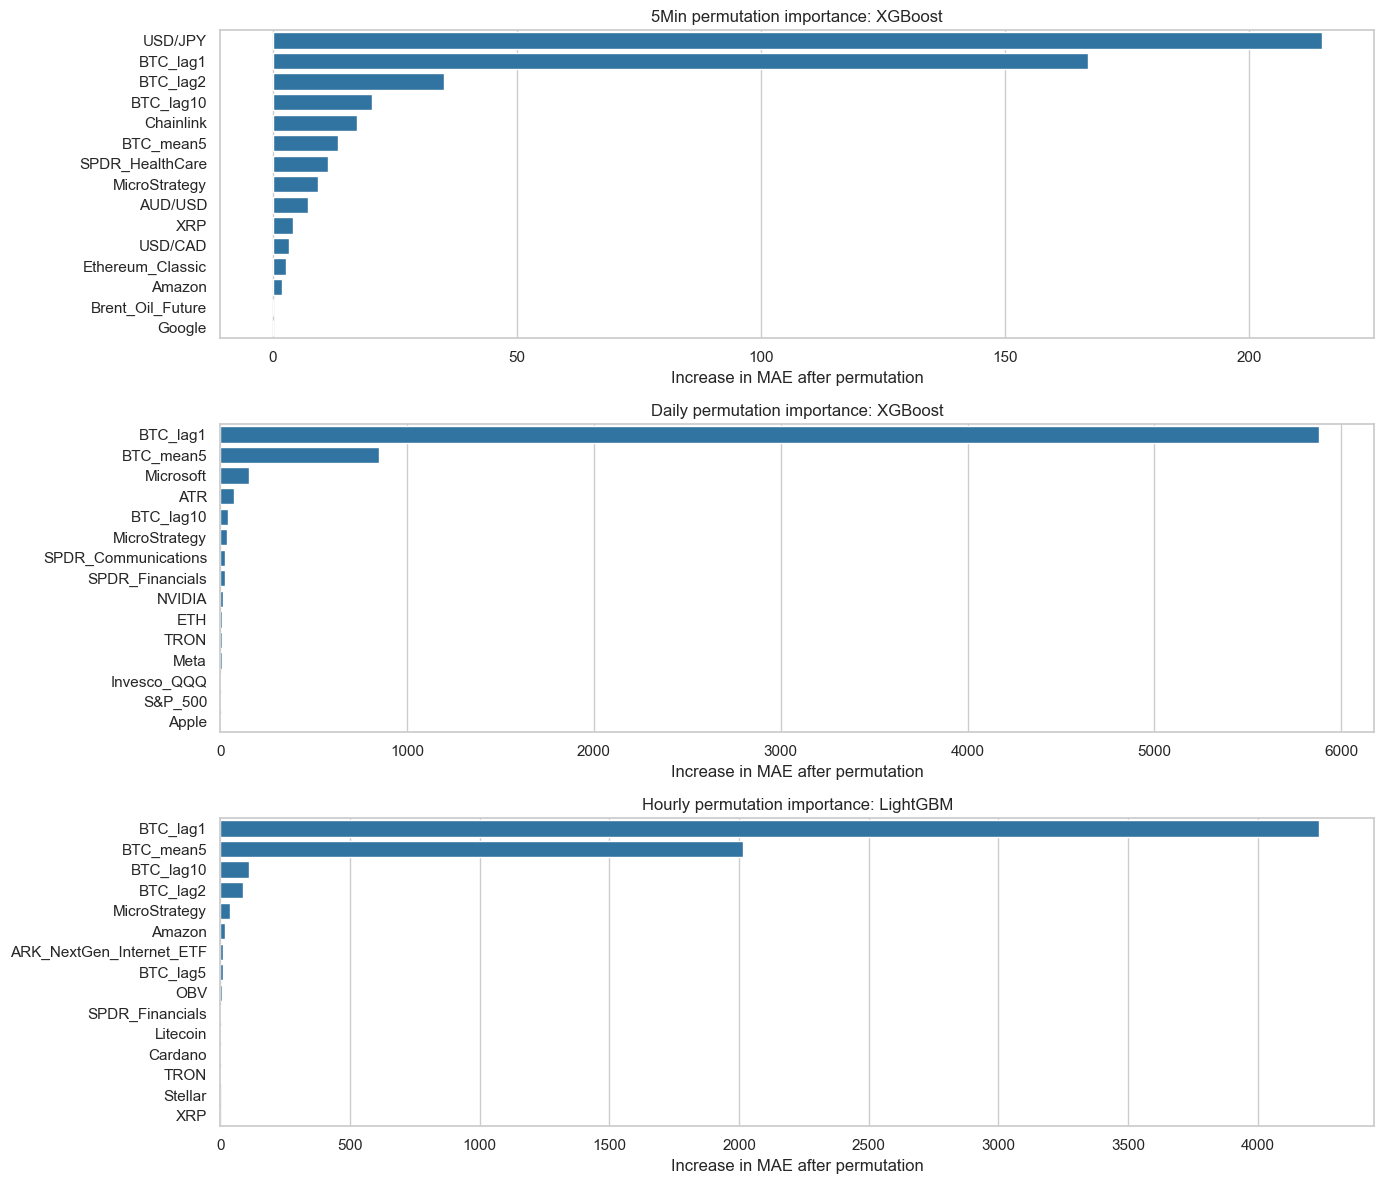

In [13]:
def permutation_importance_table(frequency, model_name, n_repeats=5, top_n=15):
    data = prepared[frequency]
    stored = prediction_store[frequency][model_name]
    model = stored['model']
    if model is None or not hasattr(model, 'predict'):
        return pd.DataFrame()
    importance = permutation_importance(
        model,
        data['X_test'],
        data['y_test'],
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        scoring='neg_mean_absolute_error',
        n_jobs=1,
    )
    table = pd.DataFrame({
        'frequency': frequency,
        'model': model_name,
        'feature': data['X_test'].columns,
        'importance_mean': importance.importances_mean,
        'importance_std': importance.importances_std,
    }).sort_values('importance_mean', ascending=False).head(top_n)
    return table

importance_tables = []
for _, row in best_gb.iterrows():
    table = permutation_importance_table(row['frequency'], row['model'])
    if not table.empty:
        importance_tables.append(table)

if importance_tables:
    importance_df = pd.concat(importance_tables, ignore_index=True)
    display(importance_df.round(4))

    fig, axes = plt.subplots(len(importance_tables), 1, figsize=(14, 4 * len(importance_tables)))
    if len(importance_tables) == 1:
        axes = [axes]
    for ax, table in zip(axes, importance_tables):
        sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:blue')
        frequency = table['frequency'].iloc[0]
        model_name = table['model'].iloc[0]
        ax.set_title(f'{frequency.title()} permutation importance: {model_name}')
        ax.set_xlabel('Increase in MAE after permutation')
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No permutation importance table was produced for the selected GB models.')


In [14]:
# Optional SHAP interpretation for the best Gradient Boosting model per frequency.
# This cell is safe to skip when shap is unavailable.
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

if HAS_SHAP:
    shap_candidates = best_gb
    for _, row in shap_candidates.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        model = prediction_store[frequency][model_name]['model']
        X_test = prepared[frequency]['X_test']
        sample = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
        estimator = model.named_steps['model'] if isinstance(model, Pipeline) else model
        transformed = model[:-1].transform(sample) if isinstance(model, Pipeline) else sample
        try:
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(transformed)
            shap.summary_plot(shap_values, sample, plot_type='bar', show=True)
        except Exception as exc:
            print(f'SHAP failed for {frequency} {model_name}: {exc}')
else:
    print('SHAP is not installed in the active environment; permutation importance above is used as the reproducible interpretation method for the GB models.')


SHAP is not installed in the active environment; permutation importance above is used as the reproducible interpretation method for the GB models.


,frequency,model,feature,importance_mean
0,5min,GRU (sequence NN),BTC_lag1,0.0315
1,5min,GRU (sequence NN),BTC_mean5,0.0304
2,5min,GRU (sequence NN),BTC_lag2,0.0186
3,5min,GRU (sequence NN),BTC_lag10,0.0090
4,5min,GRU (sequence NN),BTC_lag5,0.0072
5,5min,GRU (sequence NN),USD/JPY,0.0055
6,5min,GRU (sequence NN),OBV,0.0052
7,5min,GRU (sequence NN),Cardano,0.0050
8,5min,GRU (sequence NN),SPDR_HealthCare,0.0045
9,5min,GRU (sequence NN),Brent_Oil_Future,0.0039


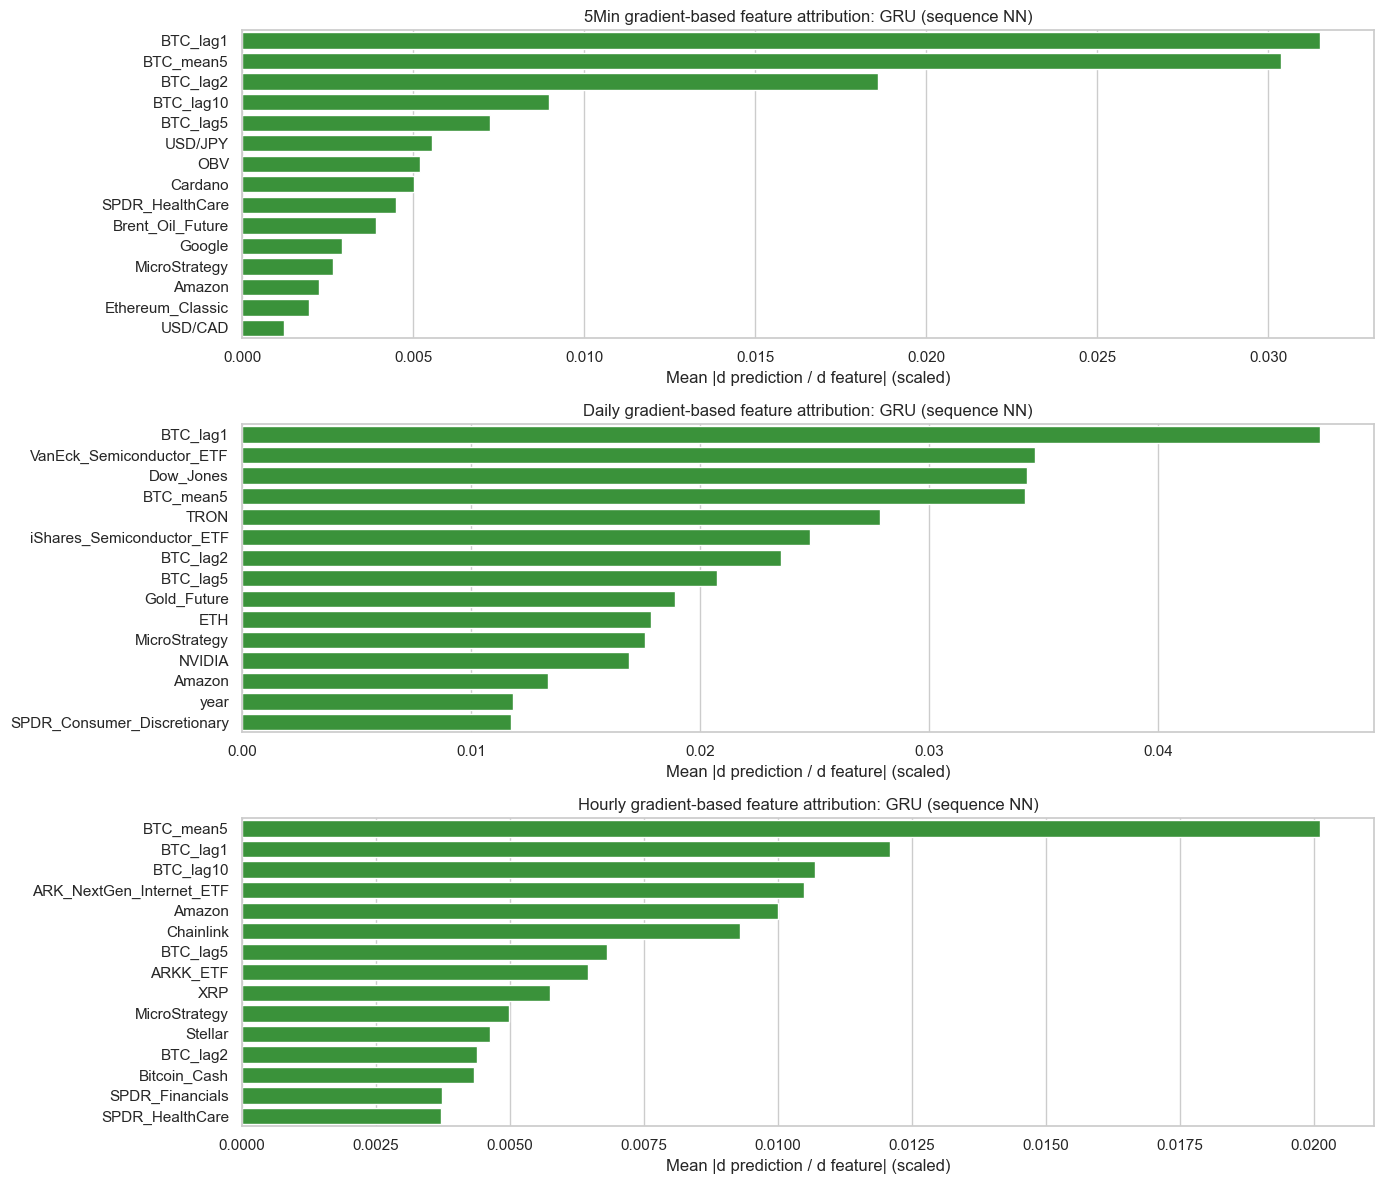

In [15]:
# Gradient-based feature attribution for the GRU (sequence NN). SHAP's TreeExplainer
# does not apply to a PyTorch model, so importance is approximated as the mean
# absolute gradient of the prediction with respect to each scaled exogenous feature.
if HAS_TORCH:
    import torch

    gru_attribution_tables = []
    for _, row in best_nn.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        extras = prediction_store[frequency][model_name]['model']
        model = extras['model']
        scaler_x = extras['scaler_x']
        scaler_y = extras['scaler_y']

        seq = prepared[frequency]['seq']
        X_seq_test = scaler_y.transform(seq['X_seq_test'].reshape(-1, 1)).reshape(seq['X_seq_test'].shape)
        X_ex_test = scaler_x.transform(seq['X_ex_test'])

        x_seq_t = torch.tensor(X_seq_test, dtype=torch.float32, device=DEVICE)
        x_ex_t = torch.tensor(X_ex_test, dtype=torch.float32, device=DEVICE, requires_grad=True)

        model.eval()
        prediction = model(x_seq_t, x_ex_t)
        prediction.sum().backward()

        gradients = x_ex_t.grad.detach().cpu().numpy()
        importance = np.abs(gradients).mean(axis=0)

        table = pd.DataFrame({
            'frequency': frequency,
            'model': model_name,
            'feature': prepared[frequency]['selected_features'],
            'importance_mean': importance,
        }).sort_values('importance_mean', ascending=False).head(15)
        gru_attribution_tables.append(table)

    if gru_attribution_tables:
        gru_attribution_df = pd.concat(gru_attribution_tables, ignore_index=True)
        display(gru_attribution_df.round(4))

        fig, axes = plt.subplots(len(gru_attribution_tables), 1, figsize=(14, 4 * len(gru_attribution_tables)))
        if len(gru_attribution_tables) == 1:
            axes = [axes]
        for ax, table in zip(axes, gru_attribution_tables):
            sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:green')
            frequency = table['frequency'].iloc[0]
            model_name = table['model'].iloc[0]
            ax.set_title(f'{frequency.title()} gradient-based feature attribution: {model_name}')
            ax.set_xlabel('Mean |d prediction / d feature| (scaled)')
            ax.set_ylabel('')
        plt.tight_layout()
        plt.show()
else:
    print('PyTorch is not available; gradient-based GRU feature attribution is skipped.')


## Error Analysis

Residual analysis covers the best Gradient Boosting model (`best_gb`) and the GRU (`best_nn`) per frequency: residual shape, temporal behavior of forecasts, and how errors compare during normal periods versus sharp BTC growth or decline (compared against the `Naive last value` baseline).


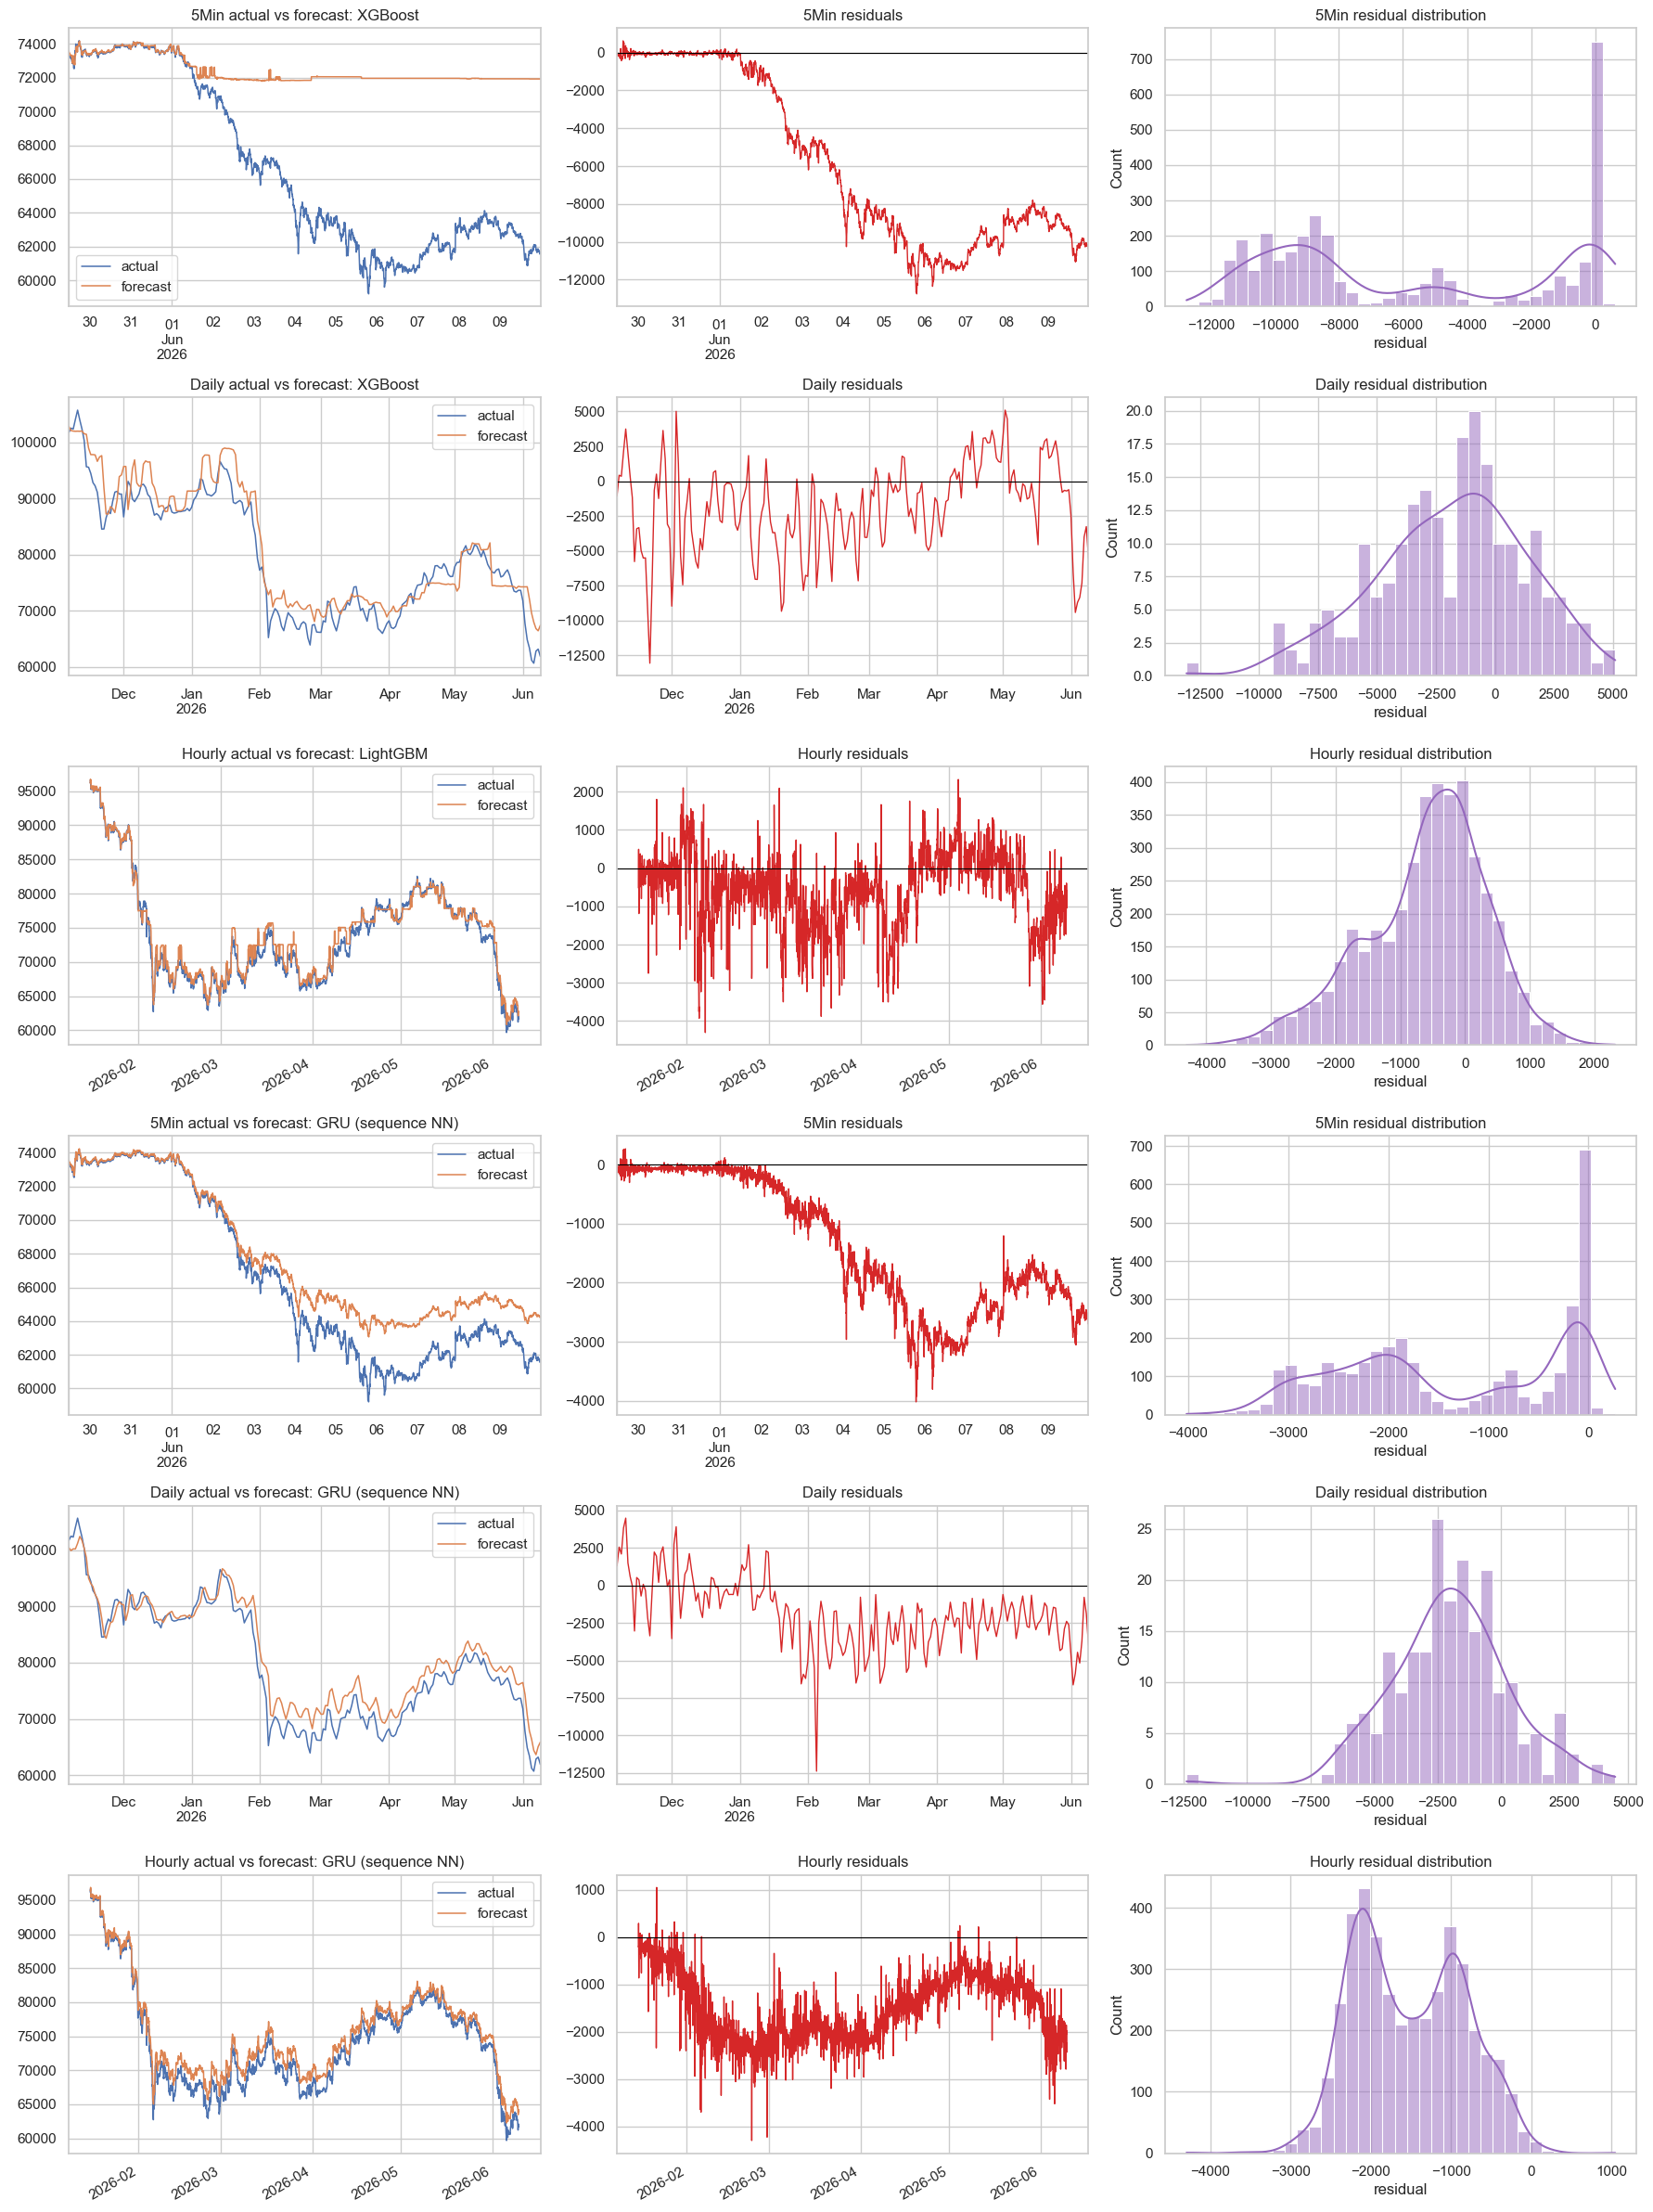

In [16]:
def residual_frame(frequency, model_name):
    y_test = prepared[frequency]['y_test']
    pred = prediction_store[frequency][model_name]['test_pred'].reindex(y_test.index)
    frame = pd.DataFrame({'actual': y_test, 'forecast': pred}).dropna()
    frame['residual'] = frame['actual'] - frame['forecast']
    frame['abs_error'] = frame['residual'].abs()
    frame['pct_return'] = frame['actual'].pct_change()
    return frame

error_analysis_rows = pd.concat([best_gb, best_nn]).reset_index(drop=True)

fig, axes = plt.subplots(len(error_analysis_rows), 3, figsize=(18, 4 * len(error_analysis_rows)))
if len(error_analysis_rows) == 1:
    axes = np.array([axes])

for row_idx, (_, row) in enumerate(error_analysis_rows.iterrows()):
    frequency = row['frequency']
    model_name = row['model']
    frame = residual_frame(frequency, model_name)

    frame[['actual', 'forecast']].plot(ax=axes[row_idx, 0], linewidth=1.1)
    axes[row_idx, 0].set_title(f'{frequency.title()} actual vs forecast: {model_name}')
    axes[row_idx, 0].set_xlabel('')

    frame['residual'].plot(ax=axes[row_idx, 1], color='tab:red', linewidth=1.0)
    axes[row_idx, 1].axhline(0, color='black', linewidth=0.8)
    axes[row_idx, 1].set_title(f'{frequency.title()} residuals')
    axes[row_idx, 1].set_xlabel('')

    sns.histplot(frame['residual'], bins=35, kde=True, ax=axes[row_idx, 2], color='tab:purple')
    axes[row_idx, 2].set_title(f'{frequency.title()} residual distribution')

plt.tight_layout()
plt.show()


In [17]:
naive_rows = results_df[(results_df['family'] == 'baseline') & (results_df['model'] == 'Naive last value')].reset_index(drop=True)
shock_candidates = pd.concat([naive_rows, best_gb, best_nn]).reset_index(drop=True)

shock_rows = []
shock_detail_rows = []
for _, row in shock_candidates.iterrows():
    frequency = row['frequency']
    model_name = row['model']
    frame = residual_frame(frequency, model_name).dropna(subset=['pct_return'])
    threshold = frame['pct_return'].abs().quantile(0.90)
    frame['shock_type'] = np.where(
        frame['pct_return'] >= threshold,
        'sharp growth',
        np.where(frame['pct_return'] <= -threshold, 'sharp drop', 'normal'),
    )

    for shock_type, group in frame.groupby('shock_type'):
        metrics = regression_metrics(group['actual'], group['forecast'], prepared[frequency]['y_train'])
        shock_rows.append({
            'frequency': frequency,
            'model': model_name,
            'period_type': shock_type,
            'n_observations': len(group),
            'MAE': metrics['MAE'],
            'SMAPE': metrics['SMAPE'],
            'MASE': metrics['MASE'],
        })

    shocks = frame[frame['shock_type'] != 'normal'].copy()
    shocks['abs_pct_return'] = shocks['pct_return'].abs()
    for time, values in shocks.sort_values('abs_pct_return', ascending=False).head(10).iterrows():
        shock_detail_rows.append({
            'frequency': frequency,
            'model': model_name,
            'time': time,
            'shock_type': values['shock_type'],
            'pct_return': values['pct_return'],
            'actual': values['actual'],
            'forecast': values['forecast'],
            'abs_error': values['abs_error'],
        })

shock_summary = pd.DataFrame(shock_rows)
shock_details = pd.DataFrame(shock_detail_rows)

display(shock_summary.round({'MAE': 2, 'SMAPE': 3, 'MASE': 3}))
display(shock_details.round({'pct_return': 4, 'actual': 2, 'forecast': 2, 'abs_error': 2}))


,frequency,model,period_type,n_observations,MAE,SMAPE,MASE
0,5min,Naive last value,normal,2985,47.71,0.073,1.094
1,5min,Naive last value,sharp drop,172,211.28,0.333,4.845
2,5min,Naive last value,sharp growth,160,237.48,0.374,5.446
3,daily,Naive last value,normal,193,873.60,1.108,1.373
4,daily,Naive last value,sharp drop,15,3626.91,4.697,5.698
5,daily,Naive last value,sharp growth,7,3065.98,4.188,4.817
6,hourly,Naive last value,normal,3764,114.15,0.155,0.593
7,hourly,Naive last value,sharp drop,227,676.82,0.947,3.518
8,hourly,Naive last value,sharp growth,192,663.43,0.939,3.449
9,5min,XGBoost,normal,2985,5572.19,8.265,127.776


,frequency,model,time,shock_type,pct_return,actual,forecast,abs_error
0,5min,Naive last value,2026-06-07 22:10:00,sharp growth,0.0214,63141.54,61818.41,1323.13
1,5min,Naive last value,2026-06-06 05:20:00,sharp growth,0.0102,60653.87,60041.16,612.71
2,5min,Naive last value,2026-06-05 20:05:00,sharp growth,0.0089,60634.06,60100.96,533.10
3,5min,Naive last value,2026-06-04 02:00:00,sharp drop,-0.0086,61572.78,62109.77,536.99
4,5min,Naive last value,2026-06-04 00:25:00,sharp drop,-0.0080,63483.03,63997.94,514.91
...,...,...,...,...,...,...,...,...
85,hourly,GRU (sequence NN),2026-02-05 20:00:00,sharp drop,-0.0258,63756.15,67454.43,3698.28
86,hourly,GRU (sequence NN),2026-01-29 15:00:00,sharp drop,-0.0224,85182.69,87581.99,2399.31
87,hourly,GRU (sequence NN),2026-03-23 11:00:00,sharp growth,0.0219,70016.00,70758.62,742.62
88,hourly,GRU (sequence NN),2026-02-25 01:00:00,sharp growth,0.0218,65577.17,66756.92,1179.75


## Discussion

This experiment is structured around the four research questions of the thesis ("Bitcoin Price Forecasting: Boosting Ensembles vs. Neural Networks").

**Q1: Which family has lower error - Gradient Boosting or the Neural Network (GRU)?**
The `headline` table reports SMAPE/MAE/RMSE/MASE for `Naive last value`, `Moving average`, `best_gb`, and the GRU at each frequency. In all three runs, `Naive last value` remains a hard benchmark because short-horizon BTC prices are close to a random walk: any model that does not at least approach persistence-level error is not adding value. Whichever of `best_gb`/GRU has the lower SMAPE per frequency is read as the stronger family for that horizon; the comment column and `train/test gap` indicate whether the gain comes with overfitting risk.

**Q2: How does the GB-vs-NN gap change across granularities (Daily -> Hourly -> 5-minute)?**
Define the gap as `SMAPE(best_gb) - SMAPE(GRU)` per frequency. A positive gap means the GRU is more accurate; a negative gap means Gradient Boosting is. Tracking this across Daily, Hourly, and 5-minute reveals whether the GRU's sequence modeling becomes relatively more or less useful as the sampling interval shrinks and the effective sequence window covers a shorter real-time horizon (the GRU window sizes in `NN_CONFIG` are fixed in observation counts, not wall-clock time, which is itself a relevant comparison point).

**Q3: Which features matter most for each family's best model?**
For `best_gb`, importance comes from permutation importance and SHAP `TreeExplainer` summary plots. For the GRU, importance comes from gradient-based attribution (mean `|d prediction / d feature|`). Overlap between the two rankings - e.g. both highlighting `BTC_lag*`/`BTC_mean5` and a handful of correlated crypto/equity series - suggests the predictive signal is robust to model choice; divergence suggests the two families exploit different parts of the feature space.

**Q4: How do error patterns differ during sharp BTC growth vs. decline?**
The shock analysis splits the test period into `normal`, `sharp growth`, and `sharp drop` segments (top/bottom 10% of period-over-period returns) and reports SMAPE/MAE/MASE for `Naive last value`, `best_gb`, and the GRU within each segment. A model that degrades less than `Naive last value` during shocks is demonstrating genuine predictive value beyond persistence during the periods that matter most for practical use (e.g. risk management); a model that degrades more is effectively "lagging" the shock, similar to the naive baseline but with extra modeling overhead.


## Conclusion

This notebook is a compact, executable comparison of Gradient Boosting ensembles (HistGradientBoosting, LightGBM, XGBoost, CatBoost - the best of which is `best_gb`) against a Neural Network sequence model (a GRU built with `CryptoNet`) for one-step-ahead BTC forecasting at Daily, Hourly, and 5-minute granularities, with `Naive last value` and `Moving average` as reference baselines.

The `headline` table answers research question 1 (which family is more accurate) and, read across frequencies, research question 2 (how the GB-vs-NN gap evolves from Daily to 5-minute). The permutation importance / SHAP results for `best_gb` and the gradient-based attribution for the GRU answer research question 3 (which features each family's best model relies on). The shock analysis answers research question 4 (how GB, the GRU, and the naive persistence baseline behave during sharp BTC growth and decline).

`Naive last value` remains a strong reference at every frequency, consistent with BTC's near-random-walk behavior at short horizons; both GB and the GRU should be read as improvements (or lack thereof) relative to that persistence baseline rather than as absolute solutions.

Main limitations: BTC non-stationarity and regime shifts, weak extrapolation of both GB and the GRU outside the train price range, a single hardcoded GRU configuration per frequency (no architecture/hyperparameter search), and the difficulty of predicting crypto shocks from historical tabular/sequence indicators alone.

Further work: walk-forward retraining and validation, hyperparameter search for the GRU and GB models, probabilistic/quantile forecasts, additional NN architectures (LSTM, CNN-LSTM) for a broader Q1/Q2 comparison, and richer on-chain or order-book features for the shock periods identified in Q4.
